# 03 · Merge — build the clean monthly analysis panel

Combines the cleaned long panel, the two CPI deflators, and the quarterly
capacity snapshots into one modelling table, and derives the inflation /
real-rate / seasonality / COVID / revenue-proxy columns.

**Key construction rules** (`DATA_AUDIT.md` §5, §10):

* Analysis window **2016-12 → 2026-05** (`in_window`); rows outside are kept for
  nominal-only descriptive plots but must never enter a CPI-deflated model.
* `real_rate = nominal_rate / cpi × 100`, base **dic-2016 = 100** → constant
  dic-2016 pesos. Built on GBA (primary) *and* national (robustness).
* Capacity is **quarterly** — attached as *as-of the nearest prior snapshot*
  in explicitly suffixed `*_asof` columns, never presented as monthly-observed.
* `revenue_proxy` and `occupied_room_nights_proxy` are labelled proxies because
  they mix monthly occupancy with quarterly-anchored capacity.

**Inputs** `02_panel_long`, `02_cpi_monthly`, `02_capacity_quarterly` →
**Output** `data/processed/03_analysis_panel.parquet`,
`outputs/tables/data_dictionary.csv`, `outputs/tables/coverage_by_category.csv`,
`outputs/figures/03_*.png`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SRC = Path.cwd().parent / "src"
sys.path.insert(0, str(SRC))
import config as C
from common import AuditLog

LOG = AuditLog("03_merge")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": C.PLOT_DPI,
                     "axes.grid": True, "grid.alpha": .3, "font.size": 9})

panel = pd.read_parquet(C.P_PANEL_LONG)
cpi = pd.read_parquet(C.P_CPI_MONTHLY)
capq = pd.read_parquet(C.P_CAPACITY_Q)

## 1 · Long → wide (one row per date × hotel_category)

In [2]:
wide = (panel.pivot_table(index=["date", "hotel_category"], columns="variable",
                          values="value", aggfunc="first", dropna=False)
        .reset_index().sort_values(["hotel_category", "date"]))
wide.columns.name = None
for v in ["average_rate", "room_occupancy", "bed_occupancy", "travelers"]:
    if v not in wide:
        wide[v] = np.nan
# carry the missing_reason for the rate (most-used series) alongside
rr = panel[panel.variable == "average_rate"][["date", "hotel_category", "missing_reason", "provisional"]]
wide = wide.merge(rr, on=["date", "hotel_category"], how="left")
wide = wide.rename(columns={"missing_reason": "rate_missing_reason",
                            "provisional": "rate_provisional"})
LOG.log("pivot", "wide panel", len(wide),
        f"{wide.date.min():%Y-%m}..{wide.date.max():%Y-%m}, "
        f"{wide.hotel_category.nunique()} categories")

  [03_merge] pivot                  wide panel                           2210  2008-01..2026-05, 10 categories


## 2 · Merge CPI, build inflation & real rates

`inflation_*` in **percent**. `cum_infl_*_3m/6m/12m` are compounded cumulative
inflation over trailing windows (percent). Real rates in constant dic-2016 pesos.

In [3]:
cpi = cpi.sort_values("date").copy()
for geo in ["gba", "nac"]:
    lvl = cpi[f"cpi_{geo}"]
    cpi[f"infl_mom_{geo}"] = lvl.pct_change() * 100
    cpi[f"infl_yoy_{geo}"] = lvl.pct_change(12) * 100
    for k in (3, 6, 12):
        cpi[f"cum_infl_{geo}_{k}m"] = (lvl / lvl.shift(k) - 1) * 100

wide = wide.merge(cpi, on="date", how="left")
for geo in ["gba", "nac"]:
    wide[f"real_rate_{geo}"] = wide["average_rate"] / wide[f"cpi_{geo}"] * 100
    wide[f"real_resthot_defl_{geo}"] = wide["average_rate"] / wide[f"cpi_resthot_{geo}"] * 100

LOG.log("cpi_merge", "real rates + inflation", wide[["infl_mom_gba"]].notna().sum().item(),
        "infl_mom_gba non-null rows")

  [03_merge] cpi_merge              real rates + inflation               1200  infl_mom_gba non-null rows


## 3 · Seasonality & time index

In [4]:
wide["month"] = wide["date"].dt.month
wide["year"] = wide["date"].dt.year
wide["t"] = (wide["date"].dt.year - 2016) * 12 + (wide["date"].dt.month - 12)  # 0 at 2016-12
for m in range(2, 13):
    wide[f"m{m:02d}"] = (wide["month"] == m).astype(int)

## 4 · COVID structural-break flags

In [5]:
d = wide["date"].dt.strftime("%Y-%m-%d")
wide["covid_hole"] = ((d >= C.COVID_HOLE_START) & (d <= C.COVID_HOLE_END)).astype(int)
wide["covid_recovery"] = ((d >= C.COVID_RECOVERY_START) & (d <= C.COVID_RECOVERY_END)).astype(int)
wide["covid_any"] = (wide["covid_hole"] | wide["covid_recovery"]).astype(int)
LOG.log("covid_flags", "hole / recovery / any",
        f"{wide.covid_hole.sum()} / {wide.covid_recovery.sum()} / {wide.covid_any.sum()}",
        "row-months across all categories")

  [03_merge] covid_flags            hole / recovery / any            220 / 120 / 340  row-months across all categories


## 5 · Capacity as-of nearest prior quarterly snapshot

`merge_asof` per category → `*_asof` columns plus `capacity_asof_date` and
`capacity_asof_lag_months` so any staleness is visible. 2008 EOH-taxonomy rows
are excluded from the as-of source (out of window anyway).

In [6]:
capq2 = capq[capq["source_taxonomy"] == "ehoba"].sort_values("date").copy()
pieces = []
for cat, g in wide.sort_values("date").groupby("hotel_category"):
    src = capq2[capq2["hotel_category"] == cat][
        ["date", "establishments", "available_room_nights", "available_bed_nights"]
    ].rename(columns={"date": "capacity_asof_date",
                      "establishments": "establishments_asof",
                      "available_room_nights": "available_room_nights_asof",
                      "available_bed_nights": "available_bed_nights_asof"})
    if src.empty:
        g = g.assign(capacity_asof_date=pd.NaT, establishments_asof=np.nan,
                     available_room_nights_asof=np.nan, available_bed_nights_asof=np.nan)
    else:
        g = pd.merge_asof(g, src, left_on="date", right_on="capacity_asof_date",
                          direction="backward")
    pieces.append(g)
wide = pd.concat(pieces, ignore_index=True)
wide["capacity_asof_lag_months"] = (
    (wide["date"].dt.year - wide["capacity_asof_date"].dt.year) * 12 +
    (wide["date"].dt.month - wide["capacity_asof_date"].dt.month))
LOG.log("capacity_asof", "merge_asof backward", wide["available_room_nights_asof"].notna().sum().item(),
        f"median lag {wide['capacity_asof_lag_months'].median():.0f} mo, "
        f"max lag {wide['capacity_asof_lag_months'].max():.0f} mo")

  [03_merge] capacity_asof          merge_asof backward                  2031  median lag 1 mo, max lag 38 mo


## 6 · Revenue proxy (labelled) & log-growth columns

`occupied_room_nights_proxy = available_room_nights_asof × room_occupancy/100`
`revenue_proxy = average_rate × occupied_room_nights_proxy`  (nominal pesos)
`real_revenue_proxy_gba = revenue_proxy / cpi_gba × 100`

In [7]:
wide["occupied_room_nights_proxy"] = (
    wide["available_room_nights_asof"] * wide["room_occupancy"] / 100)
wide["revenue_proxy"] = wide["average_rate"] * wide["occupied_room_nights_proxy"]
wide["real_revenue_proxy_gba"] = wide["revenue_proxy"] / wide["cpi_gba"] * 100

wide = wide.sort_values(["hotel_category", "date"])
g = wide.groupby("hotel_category", group_keys=False)
for col in ["average_rate", "real_rate_gba", "real_rate_nac",
            "room_occupancy", "bed_occupancy", "travelers", "revenue_proxy"]:
    wide[f"dln_{col}"] = g[col].apply(lambda s: np.log(s).diff())

## 7 · Window flag & write

In [8]:
wide["in_window"] = ((wide["date"] >= C.WINDOW_START) &
                     (wide["date"] <= C.WINDOW_END)).astype(int)
wide = wide.sort_values(["hotel_category", "date"]).reset_index(drop=True)
wide.to_parquet(C.P_ANALYSIS)
LOG.log("write", "03_analysis_panel.parquet", len(wide),
        f"{wide.in_window.sum()} in-window rows "
        f"({wide.loc[wide.in_window == 1, 'date'].min():%Y-%m}"
        f"..{wide.loc[wide.in_window == 1, 'date'].max():%Y-%m})")

  [03_merge] write                  03_analysis_panel.parquet            2210  1140 in-window rows (2016-12..2026-05)


## 8 · Data dictionary

In [9]:
dd = [
 ("date", "month (period start)", "monthly", "date"),
 ("hotel_category", "canonical category key (stars_1_2 … boutique, totals)", "—", "str"),
 ("average_rate", "avg monthly room rate, nominal pesos (Ehoba_03a)", "monthly", "ARS"),
 ("room_occupancy", "rooms occupied / available, in month (Ehoba_02a)", "monthly", "% 0-100"),
 ("bed_occupancy", "beds occupied / available, in month (Ehoba_04)", "monthly", "% 0-100"),
 ("travelers", "travellers hosted, hotel sector only (Ehoba_VA)", "monthly", "persons"),
 ("cpi_gba", "IPC Región GBA, Nivel general, base dic-2016=100 (primary)", "monthly", "index"),
 ("cpi_nac", "IPC Total nacional, Nivel general, base dic-2016=100 (robustness)", "monthly", "index"),
 ("cpi_resthot_gba", "IPC GBA division 'Restaurantes y hoteles' (context only)", "monthly", "index"),
 ("infl_mom_gba / _nac", "100·(CPI_t/CPI_{t-1}-1)", "monthly", "%"),
 ("infl_yoy_gba / _nac", "100·(CPI_t/CPI_{t-12}-1)", "monthly", "%"),
 ("cum_infl_{geo}_{3,6,12}m", "trailing compounded cumulative inflation", "monthly", "%"),
 ("real_rate_gba / _nac", "average_rate / cpi × 100 (constant dic-2016 pesos)", "monthly", "ARS const"),
 ("month, year, t", "calendar month, year, months since 2016-12 (t=0)", "monthly", "int"),
 ("m02 … m12", "calendar-month dummies (Jan = base)", "monthly", "0/1"),
 ("covid_hole", "2020-03 … 2021-12 (category detail unavailable)", "monthly", "0/1"),
 ("covid_recovery", "2022 (degraded: 1-2★ missing)", "monthly", "0/1"),
 ("covid_any", "covid_hole OR covid_recovery", "monthly", "0/1"),
 ("*_asof", "nearest PRIOR quarterly capacity snapshot (Ehoba_1_ano)", "stepped quarterly", "counts / nights"),
 ("capacity_asof_date / _lag_months", "date of that snapshot and its staleness", "monthly", "date / int"),
 ("occupied_room_nights_proxy", "available_room_nights_asof × room_occupancy/100 — PROXY", "monthly*", "room-nights"),
 ("revenue_proxy", "average_rate × occupied_room_nights_proxy — PROXY, nominal", "monthly*", "ARS"),
 ("real_revenue_proxy_gba", "revenue_proxy / cpi_gba × 100 — PROXY, constant", "monthly*", "ARS const"),
 ("dln_*", "first difference of natural log, within category", "monthly", "log pts"),
 ("in_window", "1 if 2016-12 ≤ date ≤ 2026-05 (CPI-valid analysis window)", "monthly", "0/1"),
 ("rate_missing_reason", "why average_rate is NaN (see missing_value_map.csv)", "monthly", "str"),
]
dd = pd.DataFrame(dd, columns=["variable", "definition", "frequency", "unit"])
dd.to_csv(C.P_DATA_DICT, index=False)
LOG.log("write", "data_dictionary.csv", len(dd))
dd

  [03_merge] write                  data_dictionary.csv                    26  


,variable,definition,frequency,unit
0,date,month (period start),monthly,date
1,hotel_category,"canonical category key (stars_1_2 … boutique, ...",—,str
2,average_rate,"avg monthly room rate, nominal pesos (Ehoba_03a)",monthly,ARS
3,room_occupancy,"rooms occupied / available, in month (Ehoba_02a)",monthly,% 0-100
4,bed_occupancy,"beds occupied / available, in month (Ehoba_04)",monthly,% 0-100
5,travelers,"travellers hosted, hotel sector only (Ehoba_VA)",monthly,persons
6,cpi_gba,"IPC Región GBA, Nivel general, base dic-2016=1...",monthly,index
7,cpi_nac,"IPC Total nacional, Nivel general, base dic-20...",monthly,index
8,cpi_resthot_gba,IPC GBA division 'Restaurantes y hoteles' (con...,monthly,index
9,infl_mom_gba / _nac,100·(CPI_t/CPI_{t-1}-1),monthly,%


# Checkpoint diagnostics

Everything below is for review — no modelling yet.

## D1 · Coverage by category, inside the analysis window

In [10]:
W = wide[wide.in_window == 1]
cov = (W.groupby("hotel_category")
       .agg(months=("date", "size"),
            rate_obs=("average_rate", lambda s: s.notna().sum()),
            roomocc_obs=("room_occupancy", lambda s: s.notna().sum()),
            bedocc_obs=("bed_occupancy", lambda s: s.notna().sum()),
            trav_obs=("travelers", lambda s: s.notna().sum()),
            rate_start=("average_rate", lambda s: W.loc[s.notna().index[s.notna()], "date"].min() if s.notna().any() else pd.NaT))
       )
cov["rate_obs_ex_covid"] = (W[W.covid_any == 0].groupby("hotel_category")["average_rate"]
                            .apply(lambda s: s.notna().sum()))
cov.to_csv(C.OUT_TAB / "coverage_by_category.csv")
cov

,months,rate_obs,roomocc_obs,bedocc_obs,trav_obs,rate_start,rate_obs_ex_covid
hotel_category,,,,,,,
apart,114,90,92,92,92,2016-12-01,78
boutique,114,90,92,92,92,2016-12-01,78
hostel,114,78,0,80,0,2016-12-01,78
otros_resto,114,78,79,80,0,2016-12-01,78
stars_1_2,114,78,80,80,80,2016-12-01,78
stars_3,114,90,92,92,92,2016-12-01,78
stars_4,114,90,92,92,92,2016-12-01,78
stars_5,114,90,92,92,92,2016-12-01,78
total_hoteleros,114,0,107,107,0,NaT,0


## D2 · Missing-value map (from notebook 02)

In [11]:
pd.read_csv(C.OUT_TAB / "missing_value_map.csv")

,variable,missing_reason,n
0,average_rate,NaN,1540
1,average_rate,covid_hole,176
2,average_rate,covid_recovery_gap,36
3,average_rate,provisional_gap,16
4,bed_occupancy,NaN,1984
5,bed_occupancy,covid_hole,190
6,bed_occupancy,covid_recovery_gap,36
7,room_occupancy,NaN,1794
8,room_occupancy,covid_hole,170
9,room_occupancy,covid_recovery_gap,36


## D3 · INDEC cross-check — our MoM from levels vs INDEC published MoM

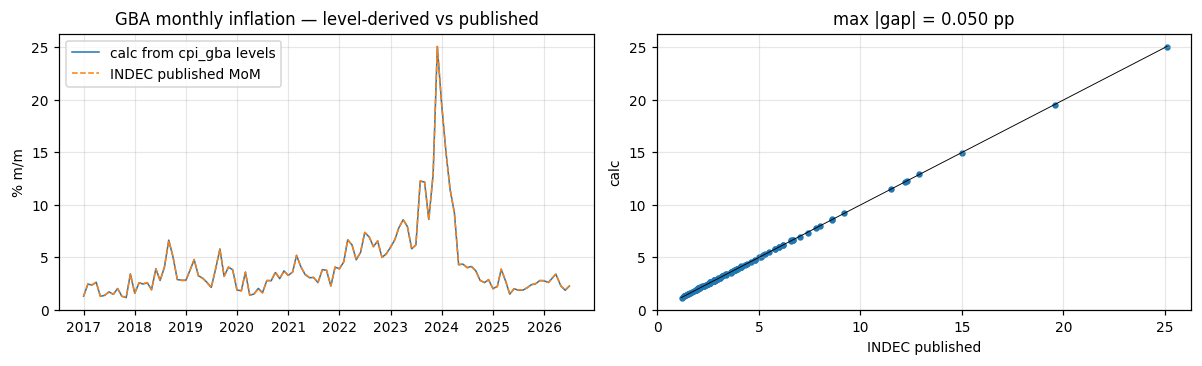

In [12]:
cc = cpi.dropna(subset=["infl_mom_gba", "indec_mom_gba_pct"]).copy()
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(cc["date"], cc["infl_mom_gba"], label="calc from cpi_gba levels", lw=1)
ax[0].plot(cc["date"], cc["indec_mom_gba_pct"], label="INDEC published MoM", lw=1, ls="--")
ax[0].set_title("GBA monthly inflation — level-derived vs published"); ax[0].legend()
ax[0].set_ylabel("% m/m")
ax[1].scatter(cc["indec_mom_gba_pct"], cc["infl_mom_gba"], s=10)
lims = [cc[["indec_mom_gba_pct", "infl_mom_gba"]].min().min(),
        cc[["indec_mom_gba_pct", "infl_mom_gba"]].max().max()]
ax[1].plot(lims, lims, "k-", lw=.6)
ax[1].set_xlabel("INDEC published"); ax[1].set_ylabel("calc")
ax[1].set_title(f"max |gap| = {(cc.infl_mom_gba - cc.indec_mom_gba_pct).abs().max():.3f} pp")
fig.tight_layout(); fig.savefig(C.OUT_FIG / "03_indec_crosscheck.png"); plt.show()

## D4 · Nominal vs real rate — sanity (4-star, both deflators)

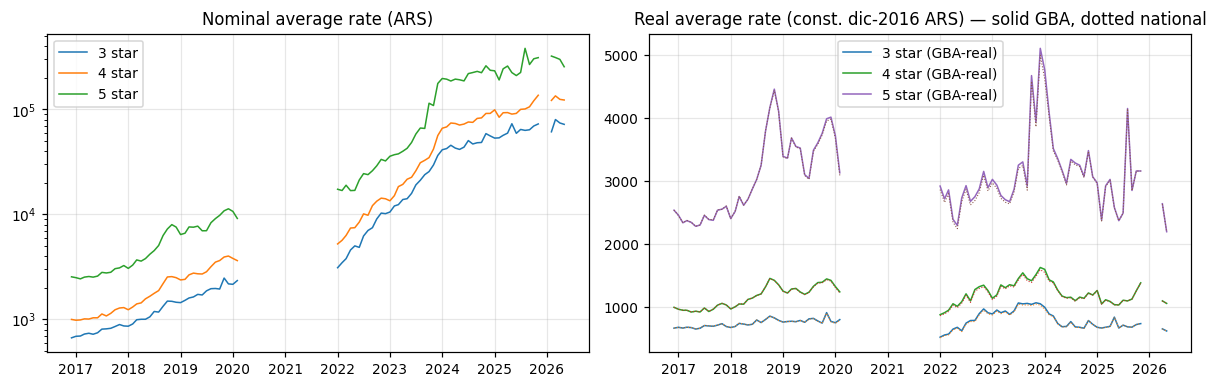

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for cat in ["stars_3", "stars_4", "stars_5"]:
    s = wide[(wide.hotel_category == cat) & (wide.in_window == 1)]
    ax[0].plot(s.date, s.average_rate, label=C.CATEGORY_LABELS[cat], lw=1)
    ax[1].plot(s.date, s.real_rate_gba, label=C.CATEGORY_LABELS[cat] + " (GBA-real)", lw=1)
    ax[1].plot(s.date, s.real_rate_nac, lw=.7, ls=":")
ax[0].set_title("Nominal average rate (ARS)"); ax[0].set_yscale("log"); ax[0].legend()
ax[1].set_title("Real average rate (const. dic-2016 ARS) — solid GBA, dotted national")
ax[1].legend()
fig.tight_layout(); fig.savefig(C.OUT_FIG / "03_nominal_vs_real.png"); plt.show()

## D5 · Descriptive Table 1 (in-window, COVID-hole excluded)

In [14]:
T = wide[(wide.in_window == 1) & (wide.covid_hole == 0) &
         (wide.hotel_category.isin(C.MODEL_CATEGORIES))]
tab1 = (T.groupby("hotel_category")
        .agg(n_months=("date", "size"),
             real_rate_gba_mean=("real_rate_gba", "mean"),
             real_rate_gba_sd=("real_rate_gba", "std"),
             room_occ_mean=("room_occupancy", "mean"),
             room_occ_sd=("room_occupancy", "std"),
             dln_rate_mean=("dln_average_rate", "mean"),
             dln_rate_sd=("dln_average_rate", "std"),
             share_rate_gt_cpi=("dln_average_rate", lambda s: np.nan))
        .round(3))
# share of months rate rose faster than CPI (GBA)
sh = (T.assign(faster=(T.dln_average_rate > np.log1p(T.infl_mom_gba / 100)))
      .groupby("hotel_category")["faster"].mean().round(3))
tab1["share_rate_gt_cpi"] = sh
tab1.to_csv(C.OUT_TAB / "table1_descriptives.csv")
tab1

,n_months,real_rate_gba_mean,real_rate_gba_sd,room_occ_mean,room_occ_sd,dln_rate_mean,dln_rate_sd,share_rate_gt_cpi
hotel_category,,,,,,,,
apart,92,1124.324,198.725,60.753,7.527,0.048,0.113,0.489
boutique,92,1934.081,318.239,66.344,7.066,0.049,0.078,0.543
stars_1_2,92,558.192,52.646,47.508,8.079,0.040,0.077,0.402
stars_3,92,769.722,122.453,61.374,7.740,0.052,0.083,0.467
stars_4,92,1194.647,176.731,64.717,8.116,0.051,0.074,0.478
stars_5,92,3085.302,618.710,62.911,9.619,0.045,0.133,0.446


## D6 · Real rate vs room occupancy — the price/quantity trade-off (raw)

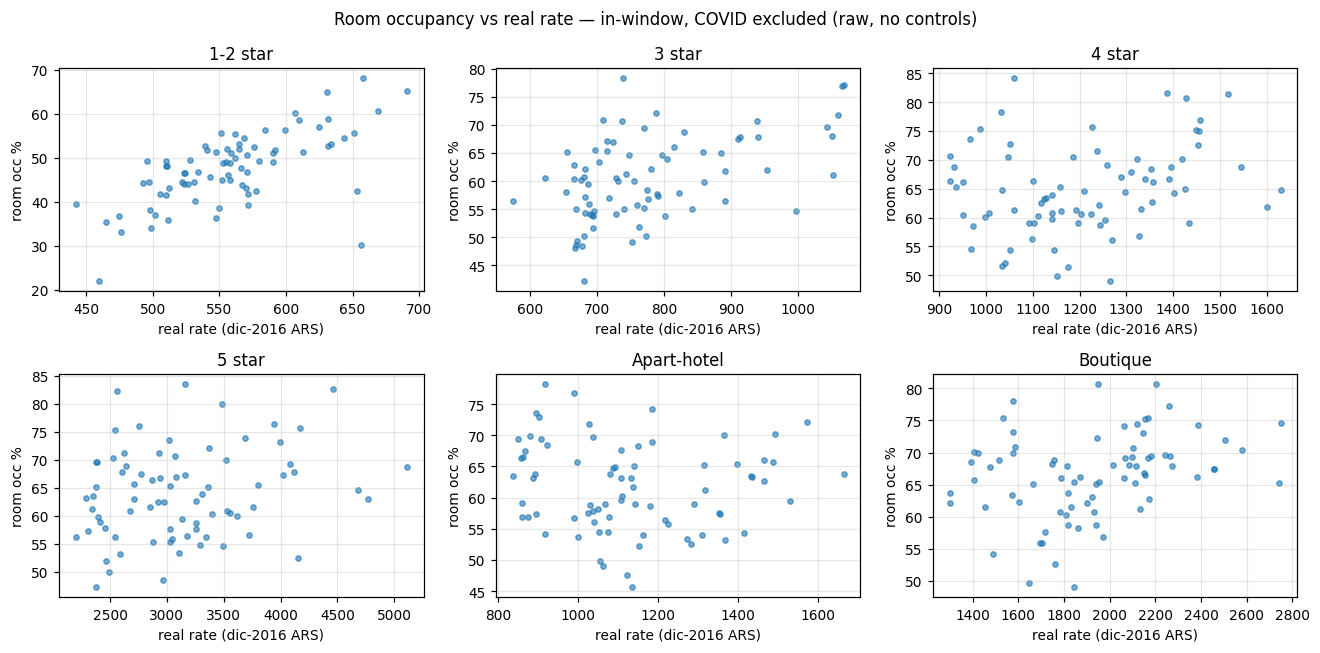

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=False)
for ax, cat in zip(axes.ravel(), C.MODEL_CATEGORIES):
    s = wide[(wide.hotel_category == cat) & (wide.in_window == 1) & (wide.covid_any == 0)]
    ax.scatter(s.real_rate_gba, s.room_occupancy, s=12, alpha=.6)
    ax.set_title(C.CATEGORY_LABELS[cat]); ax.set_xlabel("real rate (dic-2016 ARS)")
    ax.set_ylabel("room occ %")
fig.suptitle("Room occupancy vs real rate — in-window, COVID excluded (raw, no controls)")
fig.tight_layout(); fig.savefig(C.OUT_FIG / "03_occ_vs_realrate_raw.png"); plt.show()

In [16]:
LOG.flush()
print("03_merge complete — analysis panel + checkpoint diagnostics written.")

03_merge complete — analysis panel + checkpoint diagnostics written.
